In [5]:
import torch
import numpy as np
from Network.gen_z import gen_vector
from torch.utils.data import DataLoader
from Util.data_loader import loader_cre
from Util.metrics import SSIM
from Util.train_utils import train_vae, plot_curve
from Util.Visualize import Plot
import os
import torch.optim as optim


In [6]:
input_folder = r'D:\研三\代码\VAE\cpsd1022'

# 获取文件夹中所有的.npy文件
npy_files = [f for f in os.listdir(input_folder) if f.endswith('.npy')]

# 初始化一个空的列表，用来存储每个文件的数据
all_data = []

# 读取每个.npy文件，并将其加载到all_data列表中
for npy_file in npy_files:
    file_path = os.path.join(input_folder, npy_file)
    data = np.load(file_path)
    all_data.append(data)

# 将所有数据合并成一个Tensor
# 假设每个文件的数据维度是 (513, 125)，则合并后的形状是 (400, 513, 125)
tensor_data = torch.tensor(np.array(all_data))  # 将列表转换为NumPy数组，再转为Tensor

# 计算整个数据集的均值和标准差
mean = tensor_data.mean(dim=(0, 1))  # 按第1和第2维计算均值
std = tensor_data.std(dim=(0, 1))    # 按第1和第2维计算标准差
# 标准化数据
normalized_tensor = (tensor_data - mean) / std

In [8]:
from torch.utils.data import Dataset
class CustomDataset(Dataset):
    def __init__(self, data):
        """
        初始化数据集
        :param data: 数据 Tensor，形状为 (400, 125, 513)
        """
        self.data = data

    def __len__(self):
        """
        返回数据集的大小（样本数），即第一维度的大小
        """
        return self.data.shape[0]

    def __getitem__(self, idx):
        """
        返回指定索引的样本，形状为 (125, 513)
        :param idx: 样本索引
        """
        sample = self.data[idx]
        sample = sample.unsqueeze(0)
        return sample  # 直接返回指定样本的数据，形状是 (125, 513)

# 创建数据集实例
dataset = CustomDataset(normalized_tensor)


In [21]:
import random
random_integer = random.randint(1, 100)


In [22]:
print(random_integer)

56


In [23]:
#model = VAE()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model.to(device)

save_path = "./weight/std_kl_01.pth"
input_data = dataset[random_integer]
input_data = input_data.unsqueeze(0)
input_data = input_data.to(device)
vector = gen_vector(save_path, input_data, device)

In [24]:
print(vector)

tensor([[ 1.8404e+00, -2.5090e+00,  5.3500e-01,  5.4027e+03, -4.0402e-01,
         -1.5033e+00, -3.3667e-01,  2.3600e+00,  7.8537e-01,  6.8577e-01,
          1.1322e+00,  6.9785e-01,  1.8113e+00,  7.4564e-01,  1.2542e+01,
          6.2327e-01, -9.2911e-01,  1.0765e+00,  2.7918e-01,  6.4593e-01,
         -9.3895e-01,  1.8993e+00, -7.4967e-01, -4.8291e-01,  9.9973e-01,
          2.1668e+00, -4.4361e-01,  2.6598e+00,  1.6777e+00,  1.0972e+00,
          1.3079e+00,  2.2807e+00]], device='cuda:0', grad_fn=<AddBackward0>)


In [32]:
vector_cpu = vector.detach().cpu().numpy()
print(vector_cpu)

[[ 1.8404291e+00 -2.5089993e+00  5.3500038e-01  5.4026943e+03
  -4.0402102e-01 -1.5033007e+00 -3.3667353e-01  2.3599579e+00
   7.8536832e-01  6.8577397e-01  1.1321760e+00  6.9784546e-01
   1.8112643e+00  7.4563783e-01  1.2541568e+01  6.2326658e-01
  -9.2910635e-01  1.0764635e+00  2.7917862e-01  6.4592946e-01
  -9.3894744e-01  1.8993185e+00 -7.4966949e-01 -4.8291487e-01
   9.9972963e-01  2.1667964e+00 -4.4360834e-01  2.6598420e+00
   1.6776955e+00  1.0971701e+00  1.3078960e+00  2.2806942e+00]]


In [37]:
print(vector_cpu.T.shape)

(32, 1)


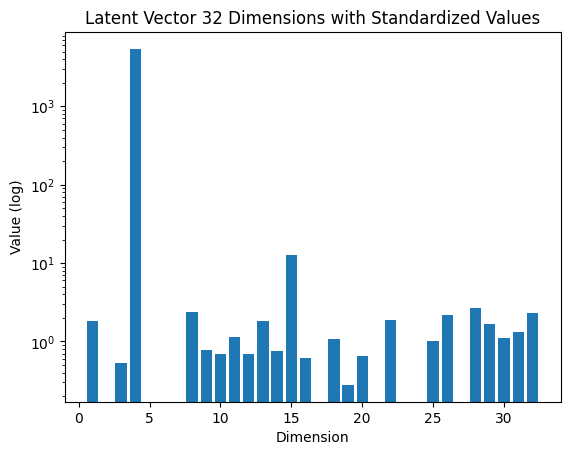

In [44]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

data = vector.detach().cpu().numpy().flatten()

# 绘制柱状图
x = np.arange(1, 33)
plt.bar(x, data)
plt.yscale('log') 
plt.title("Latent Vector 32 Dimensions with Standardized Values")
plt.xlabel("Dimension")
plt.ylabel("Value (log)")
plt.show()


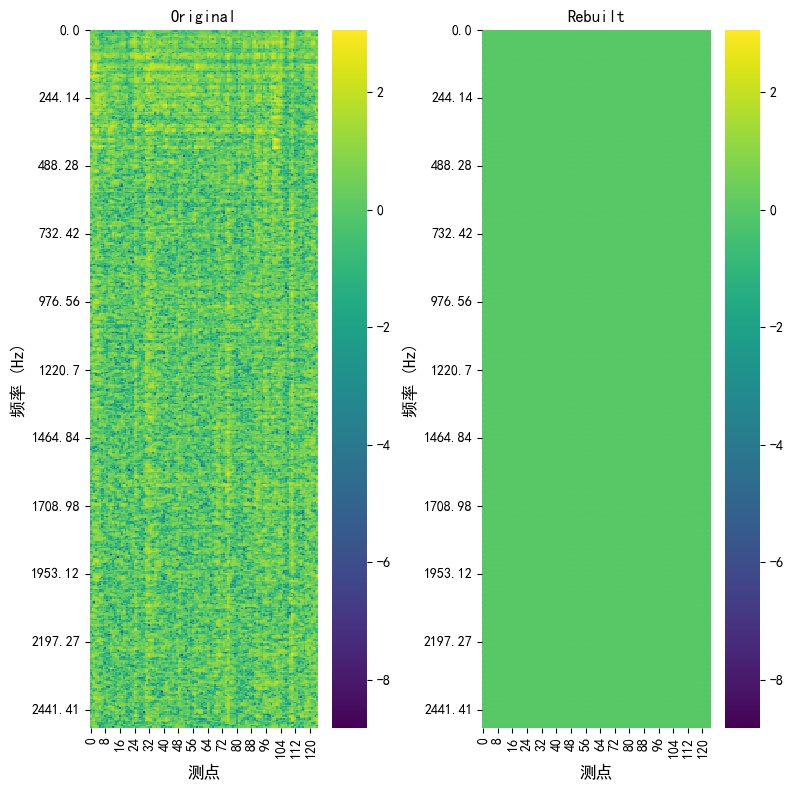

In [4]:
Plot(model, test_loader, device, index = 5)

In [5]:
ssim_rebuilt, ssim_sample = SSIM(model, test_loader, device)

原图 vs 重构图 SSIM: 0.0001862702629296109
两随机样本之间的 SSIM: 0.008487194776535034
